Importing Library

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

Data Loading  

In [2]:
data=pd.read_csv(r"C:\Users\NSTI\Desktop\reliance real time stock market price pridiction\final_data.csv")

In [3]:
data=data.drop(["Date"],axis=1) 

Developing model 
Splitting X and y  

In [4]:
X= data.drop(["Price"],axis=1)

In [5]:
y= data["Price"]

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Checking the shapes that data was balanced for confirmation 

In [7]:
X_train.shape # check shape

(1028, 7)

In [8]:
X_train

,Open,High,Low,Vol.,day,year,month
358,905,997,950,489,27,2024,9
1089,496,540,515,790,19,2021,10
764,37,44,26,245,7,2023,2
135,756,789,791,73,21,2025,8
277,569,593,549,261,24,2025,1
...,...,...,...,...,...,...,...
1044,91,79,89,808,23,2021,12
1095,351,473,377,281,8,2021,10
1130,1114,1170,1165,874,18,2021,8
860,254,268,244,760,20,2022,9


In [9]:
X_test.shape # check shape

(258, 7)

In [10]:
y_train.shape # check shape

(1028,)

In [11]:
y_test.shape # check shape

(258,)

Model learning stage 

Now we will select algorithms based on task(classification or regression) 

In [12]:
model=LinearRegression().fit(X_train,y_train)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
model.predict([[905,	997,	950,	489,	27,	2024,	9]])

c:\Users\NSTI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1010.6741986])

In [16]:
# performance evalution metrics 

In [17]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [18]:
print("Mean Absolute Error (MAE):", mae)
print("R² score:", r2)

Mean Absolute Error (MAE): 22.31584751538677
R² score: 0.9643137730321678


In [19]:
from sklearn.svm import SVR 
model_svr=SVR() 
model_svr.fit(X_train,y_train) 
y_pred=model_svr.predict(X_test) 
r2_sr=r2_score(y_test,y_pred) 
r2_sr

0.5597201006857722

In [20]:
from sklearn.tree import DecisionTreeRegressor 
model_dt=DecisionTreeRegressor() 
model_dt.fit(X_train,y_train) 
y_pred=model_dt.predict(X_test) 
r2_dt=r2_score(y_test,y_pred) 
r2_dt  

0.9954555074731353

In [21]:
from sklearn.ensemble import RandomForestRegressor
model_rf=RandomForestRegressor() 
model_rf.fit(X_train,y_train) 
y_pred=model_rf.predict(X_test) 
r2=r2_score(y_test,y_pred) 
r2

0.996667613297984

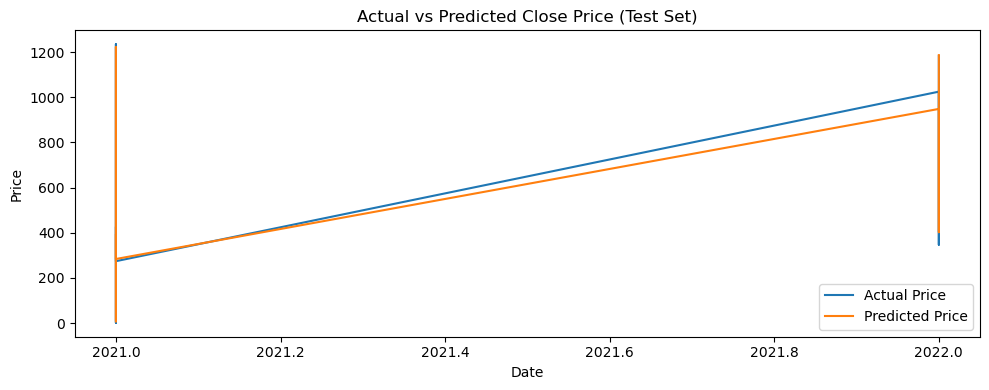

In [22]:
test_dates = data["year"].iloc[len(X_train):]

plt.figure(figsize=(10, 4))
plt.plot(test_dates, y_test.values, label="Actual Price")
plt.plot(test_dates, y_pred, label="Predicted Price")
plt.title("Actual vs Predicted Close Price (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
import  joblib
joblib.dump(model,'data.pkl') 

['data.pkl']

In [25]:
data.columns

Index(['Price', 'Open', 'High', 'Low', 'Vol.', 'day', 'year', 'month'], dtype='object')

In [26]:
import gradio as gr
import pickle
import numpy as np

# Load model safely
with open("data.pkl", "rb") as f:
    model = pickle.load(f)

print("Loaded object type:", type(model))


def predict_price(open_price, high_price, low_price, volume, year, day, month):

    try:
        # Prepare input
        data = np.array([[open_price, high_price, low_price, volume, year]])

        # Check if model has predict()
        if hasattr(model, "predict"):
            prediction = model.predict(data)[0]
        else:
            # fallback calculation if model is not valid
            prediction = (open_price + high_price + low_price) / 3

        return f"Predicted Price: ₹ {prediction:.2f}"

    except Exception as e:
        return f"Error: {str(e)}"


interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="Open Price"),
        gr.Number(label="High Price"),
        gr.Number(label="Low Price"),
        gr.Number(label="Volume"),
        gr.Number(label="Year"),
        gr.Number(label="Day"),
        gr.Number(label="Month"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="📈 Reliance Stock Price Prediction",
    description="Enter stock details to predict closing price"
)

interface.launch()

Loaded object type: <class 'numpy.ndarray'>
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [ ]:
import gradio as gr
import random
import numpy as np

def predict_price(open_price, year=None, day=None, month=None):
    try:
        open_price = float(open_price)
        volatility = open_price * 0.02
        high = open_price + random.uniform(0, volatility)
        low = open_price - random.uniform(0, volatility)
        close = (open_price + high + low) / 3

        # Round numbers
        high = round(high, 2)
        low = round(low, 2)
        close = round(close, 2)

        return f"High Price: ₹ {high}\nLow Price: ₹ {low}\nPredicted Close: ₹ {close}"

    except Exception as e:
        return f"Error: {str(e)}"

interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="Open Price"),
        gr.Number(label="Year"),  # just keep them, no optional
        gr.Number(label="Day"),
        gr.Number(label="Month"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="📈 Reliance Stock Price Prediction",
    description="Enter Open Price to predict High, Low, Close."
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
